## Import Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

In [2]:
df = pd.read_csv("car_evaluation.csv")

In [3]:
df.columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

In [4]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


## Distribusi Kelas

In [5]:
print(df['class'].value_counts())

class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [6]:
df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df.dtypes

buying      object
maint       object
doors       object
persons     object
lug_boot    object
safety      object
class       object
dtype: object

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1727 non-null   object
 1   maint     1727 non-null   object
 2   doors     1727 non-null   object
 3   persons   1727 non-null   object
 4   lug_boot  1727 non-null   object
 5   safety    1727 non-null   object
 6   class     1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [10]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


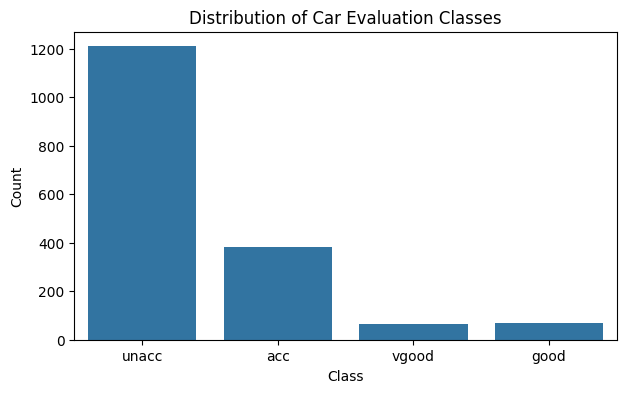

In [11]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='class')
plt.title("Distribution of Car Evaluation Classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

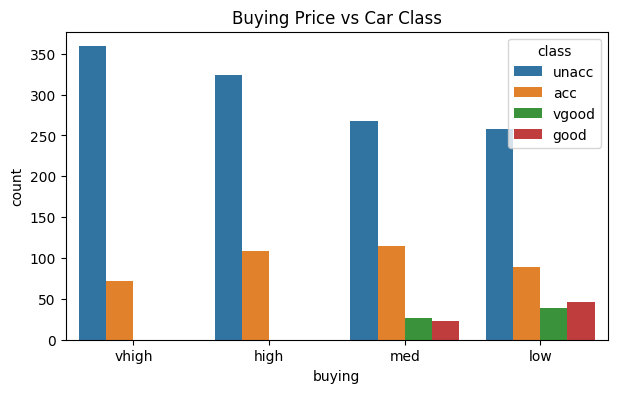

In [12]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='buying', hue='class')
plt.title("Buying Price vs Car Class")
plt.show()

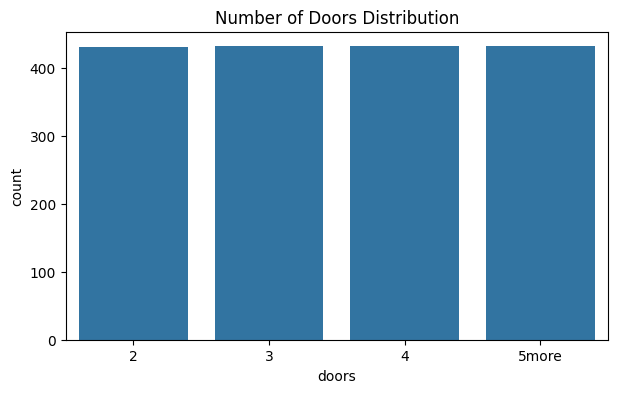

In [13]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='doors')
plt.title("Number of Doors Distribution")
plt.show()

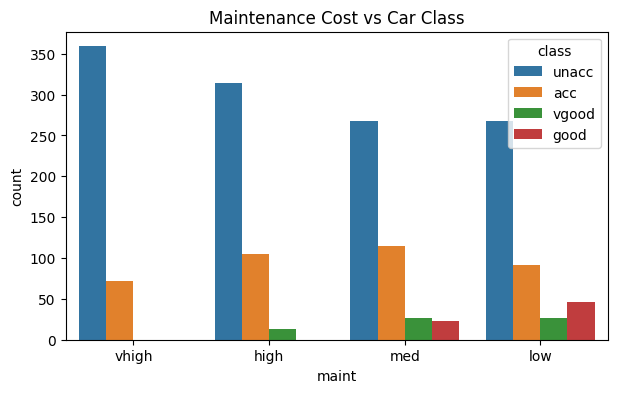

In [14]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='maint', hue='class')
plt.title("Maintenance Cost vs Car Class")
plt.show()

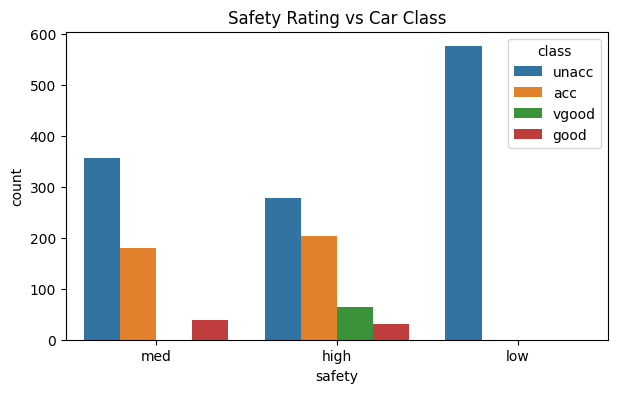

In [15]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='safety', hue='class')
plt.title("Safety Rating vs Car Class")
plt.show()

In [16]:
df['class'] = df['class'].replace({
    'good': 'acc',
    'vgood': 'acc'
})

In [17]:
def label_encode(df):
    mappings = {}
    df_encoded = df.copy()

    for col in df.columns:
        unique_vals = df[col].unique()
        mapping = {val: idx for idx, val in enumerate(unique_vals)}
        df_encoded[col] = df[col].map(mapping)
        mappings[col] = mapping

    return df_encoded, mappings


df_encoded, encoders = label_encode(df)

X = df_encoded.drop("class", axis=1).values
y = df_encoded["class"].values

In [18]:
def train_test_split(X, y, test_size=0.2):
    indices = np.arange(len(X))
    np.random.shuffle(indices)

    split = int(len(X) * (1 - test_size))
    train_idx, test_idx = indices[:split], indices[split:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


X_train, X_test, y_train, y_test = train_test_split(X, y)


In [19]:
class NaiveBayes:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.class_prob = {}
        self.feature_prob = {}

        for cls in self.classes:
            X_cls = X[y == cls]
            self.class_prob[cls] = len(X_cls) / len(X)

            self.feature_prob[cls] = []
            for i in range(X.shape[1]):
                values, counts = np.unique(X_cls[:, i], return_counts=True)
                total = sum(counts)
                probs = {}

                for v, c in zip(values, counts):
                    probs[v] = (c + self.alpha) / (total + self.alpha * len(values))

                self.feature_prob[cls].append(probs)

    def predict(self, X):
        predictions = []

        for x in X:
            posteriors = {}

            for cls in self.classes:
                posterior = np.log(self.class_prob[cls])

                for i, val in enumerate(x):
                    probs = self.feature_prob[cls][i]
                    posterior += np.log(probs.get(val, self.alpha / (self.alpha + 1)))

                posteriors[cls] = posterior

            predictions.append(max(posteriors, key=posteriors.get))

        return np.array(predictions)


In [20]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


In [21]:
class GeneticsAlgorithmTuner: 
    def __init__(
        self,
        X_train,
        y_train,
        X_val,
        y_val,
        pop_size=10,
        generations=15,
        mutation_rate=0.01,
        alpha_min=0.0001,
        alpha_max=5.0
    ): 
        self.X_train = X_train
        self.y_train = y_train 
        self.X_val = X_val 
        self.y_val = y_val 
        self.pop_size = pop_size 
        self.generations = generations 
        self.mutation_rate = mutation_rate
        self.alpha_min = alpha_min
        self.alpha_max = alpha_max
        self.population = [] 

    # -------------------------
    # Inisialisasi Populasi
    # -------------------------
    def init_pop(self): 
        print(f"Initializing population with {self.pop_size} individuals")
        self.population = [
            random.uniform(self.alpha_min, self.alpha_max)
            for _ in range(self.pop_size)
        ]

    # -------------------------
    # Fitness Function
    # -------------------------
    def fitness(self, alpha): 
        model = NaiveBayes(alpha=alpha) 
        model.fit(self.X_train, self.y_train) 

        preds = model.predict(self.X_val)

        correct = sum(
            1 for p, t in zip(preds, self.y_val) if p == t
        )
        accuracy = correct / len(self.y_val)

        return accuracy
    
    # -------------------------
    # Tournament Selection
    # -------------------------
    def selection(self, scored_population): 
        parents = []
        for _ in range(self.pop_size): 
            contender_a = random.choice(scored_population)
            contender_b = random.choice(scored_population)

            if contender_a[1] > contender_b[1]: 
                parents.append(contender_a[0])
            else: 
                parents.append(contender_b[0])
        return parents
    
    # -------------------------
    # Crossover
    # -------------------------
    def crossover(self, parents): 
        offspring = [] 
        for i in range(0, self.pop_size, 2): 
            parent1 = parents[i]
            parent2 = parents[i+1] if i+1 < len(parents) else parents[0]

            child1 = (parent1 + parent2) / 2
            child2 = (parent1 * 0.7) + (parent2 * 0.3)

            offspring.extend([child1, child2])

        return offspring[:self.pop_size]
    
    # -------------------------
    # Mutation
    # -------------------------
    def mutation(self, population): 
        mutated_pop = [] 
        for alpha in population: 
            if random.random() < self.mutation_rate: 
                noise = random.uniform(-0.5, 0.5)
                new_alpha = abs(alpha + noise)

                # pastikan alpha tetap di range
                new_alpha = max(self.alpha_min, min(new_alpha, self.alpha_max))
                mutated_pop.append(new_alpha)
            else: 
                mutated_pop.append(alpha)
        return mutated_pop
    
    # -------------------------
    # Main GA Loop
    # -------------------------
    def run(self): 
        self.init_pop()

        global_best_alpha = None
        global_best_acc = -1

        for gen in range(self.generations): 
            scores = [] 
            for alpha in self.population: 
                acc = self.fitness(alpha) 
                scores.append((alpha, acc)) 

            # sort berdasarkan fitness
            scores.sort(key=lambda x: x[1], reverse=True)

            gen_best_alpha, gen_best_acc = scores[0]

            # SIMPAN GLOBAL BEST (INI KUNCI UTAMANYA)
            if gen_best_acc > global_best_acc:
                global_best_acc = gen_best_acc
                global_best_alpha = gen_best_alpha

            print(
                f"gen {gen+1}: best: "
                f"alpha = {gen_best_alpha:.4f}, "
                f"accuracy = {gen_best_acc*100:.2f}%"
            )

            parents = self.selection(scores)
            next_gen = self.crossover(parents)
            self.population = self.mutation(next_gen)

        print(
            f"\nGlobal Best -> "
            f"alpha = {global_best_alpha:.4f}, "
            f"accuracy = {global_best_acc*100:.2f}%"
        )

        return global_best_alpha


In [22]:
ga_tuner = GeneticsAlgorithmTuner(
    X_train=X_train,
    y_train=y_train,
    X_val=X_test,
    y_val=y_test,
    pop_size=10,
    generations=15,
    mutation_rate=0.01
)

best_alpha = ga_tuner.run()

final_model = NaiveBayes(alpha=best_alpha)
final_model.fit(X_train, y_train)

final_preds = final_model.predict(X_test)

final_acc = sum(
    1 for p, t in zip(final_preds, y_test) if p == t
) / len(y_test)

print("Best Alpha:", best_alpha)
print("Final Accuracy:", final_acc)

Initializing population with 10 individuals
gen 1: best: alpha = 0.1252, accuracy = 91.91%
gen 2: best: alpha = 0.2180, accuracy = 91.33%
gen 3: best: alpha = 0.2800, accuracy = 88.73%
gen 4: best: alpha = 0.3497, accuracy = 86.99%
gen 5: best: alpha = 0.3357, accuracy = 86.99%
gen 6: best: alpha = 0.3389, accuracy = 86.99%
gen 7: best: alpha = 0.3508, accuracy = 86.99%
gen 8: best: alpha = 0.3391, accuracy = 86.99%
gen 9: best: alpha = 0.3392, accuracy = 86.99%
gen 10: best: alpha = 0.3393, accuracy = 86.99%
gen 11: best: alpha = 0.3394, accuracy = 86.99%
gen 12: best: alpha = 0.3394, accuracy = 86.99%
gen 13: best: alpha = 0.3394, accuracy = 86.99%
gen 14: best: alpha = 0.3394, accuracy = 86.99%
gen 15: best: alpha = 0.3394, accuracy = 86.99%

Global Best -> alpha = 0.1252, accuracy = 91.91%
Best Alpha: 0.1251512750378124
Final Accuracy: 0.9190751445086706


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

y_pred = final_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="binary", pos_label=1)
recall = recall_score(y_test, y_pred, average="binary", pos_label=1)
f1 = f1_score(y_test, y_pred, average="binary", pos_label=1)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nConfusion Matrix:")
print(cm)

Accuracy : 0.9190751445086706
Precision: 0.8990825688073395
Recall   : 0.8521739130434782
F1-score : 0.875

Confusion Matrix:
[[220  11]
 [ 17  98]]
